# $visit_{n-1} - visit_{n} \rightarrow fatigue_{n-1} - fatigue_{n}$
$\Delta visit \rightarrow \Delta fatigue$ \
Finds difference from **previous** visit to current visit **using daily DMOs**

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.train.train_regression_xv import LSTMRegressionXV
from src.core.data_transforms import Transform


import torch


/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=175,
    hidden_size=128,
    num_layers=1,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [5]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [6]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [8]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [9]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [10]:
#dmo_data = dmo_data.mean(axis=2)

In [11]:
print(dmo_data.shape)
print(dmo_labels.shape)

torch.Size([428, 4, 7, 25])
torch.Size([428, 4, 1])


In [12]:
# Min max normalise the labels globally

label_normaliser = Normaliser(MinMaxScaler())
dmo_labels = label_normaliser.scaler_fit_transform(dmo_labels)

In [13]:
def format_input_data_delta_visit(input_data):
    if len(input_data.shape) < 4:
            input_data = input_data.unsqueeze(dim=0)

    patients, visits, days, features = input_data.shape

    delta_visits = torch.zeros(patients, visits - 1, days, features)
    for patient in range(patients):
        
        delta_visits[patient] = input_data[patient, 1:] - input_data[patient, :-1]

    return delta_visits

def format_label_data_delta_visit(label_data):
    patients, visits, labels = label_data.shape
    
    delta_labels = torch.zeros(patients, (visits - 1), labels)
    for patient in range(patients):
        delta_labels[patient] = label_data[patient, 1:] - label_data[patient, :-1]

    return delta_labels


In [14]:
dmo_data = format_input_data_delta_visit(dmo_data)
dmo_labels = format_label_data_delta_visit(dmo_labels)

In [15]:
dmo_data = dmo_data.flatten(start_dim=2, end_dim=3)

In [16]:
dmo_data.shape

torch.Size([428, 3, 175])

In [17]:
xv_trainer = LSTMRegressionXV(dmo_data, dmo_labels, config, device, k=K_FOLDS)
prediction, actual = xv_trainer.train_cross_validation()

Testing loss: 0.0396118431041638
<class 'list'>
[tensor([[ 0.0212],
        [ 0.1533],
        [-0.2943]]), tensor([[ 0.0348],
        [-0.2398],
        [ 0.0094]]), tensor([[-0.1077],
        [ 0.2636],
        [-0.0744]]), tensor([[0.0412],
        [0.1392],
        [0.0983]]), tensor([[0.0149],
        [0.0191],
        [0.0680]]), tensor([[ 0.0661],
        [ 0.3740],
        [-0.0215]]), tensor([[-0.0569],
        [ 0.1339],
        [-0.0695]]), tensor([[-0.0068],
        [ 0.1214],
        [-0.0422]]), tensor([[-0.0631],
        [-0.2587],
        [ 0.2480]]), tensor([[-0.1223],
        [-0.0464],
        [-0.0172]]), tensor([[0.0557],
        [0.1749],
        [0.0432]]), tensor([[ 0.0635],
        [ 0.0187],
        [-0.0589]]), tensor([[0.0552],
        [0.0962],
        [0.3386]]), tensor([[ 0.1343],
        [-0.1365],
        [-0.0955]]), tensor([[-0.0328],
        [-0.0252],
        [-0.0042]]), tensor([[ 0.1307],
        [ 0.1657],
        [-0.1777]]), tensor([[ 0.2294],


In [18]:
prediction = torch.concatenate(prediction).flatten().reshape(dmo_labels.shape)
prediction = label_normaliser.scaler_inverse_labels(prediction).flatten()
prediction.shape

torch.Size([1284])

In [19]:
actual = torch.concatenate(actual).flatten().reshape(dmo_labels.shape)
actual = label_normaliser.scaler_inverse_labels(actual).flatten()
actual.shape

torch.Size([1284])

In [20]:
print(xv_trainer.R2_values)

[-0.7576932907104492, -0.3787487745285034, -0.49932992458343506, -0.3130906820297241, -0.6017986536026001]


All metrics: {'accuracy': 0.008566978193146417, 'Mean Squared Error': 49.134132385253906, 'Mean Absolute Error': 5.441012382507324, 'R^2': -0.4943924410199658}


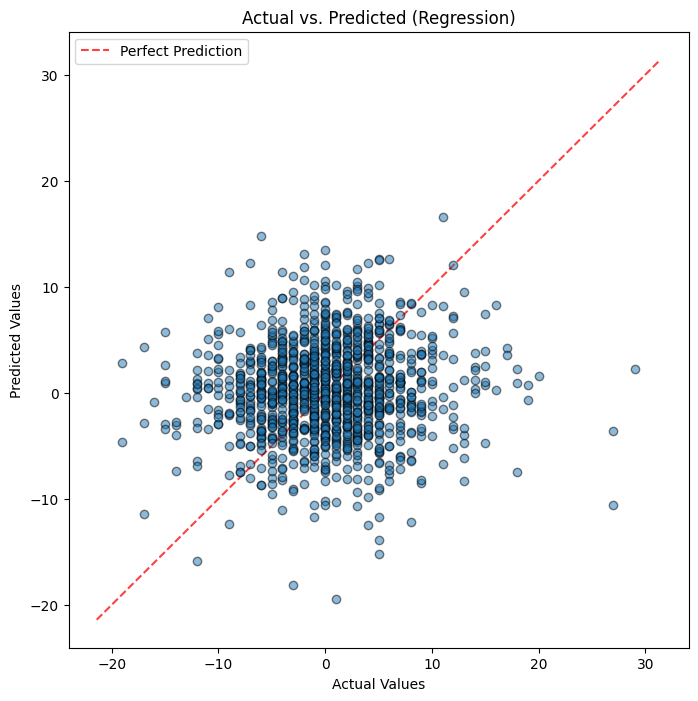

In [21]:
from src.evaluation import Evaluation

evaluation = Evaluation(prediction, actual)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
